# Unconstrained Optimization: Gradient Descent and Newton's Method

This notebook builds up the algorithmic toolkit for unconstrained optimization, starting from first
principles (Taylor expansion) and ending with L-BFGS — the workhorse of large-scale optimization.

**Prerequisites:** Notebook 01 (NLP intro), multivariable calculus.

**Series:** Notebook 2 of 5.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve as linalg_solve

plt.rcParams.update({'figure.dpi': 100, 'font.size': 12})

# ---- Test problem: Rosenbrock ----
def rosenbrock(x):
    return (1 - x[0])**2 + 100*(x[1] - x[0]**2)**2

def rosenbrock_grad(x):
    g0 = -2*(1 - x[0]) - 400*x[0]*(x[1] - x[0]**2)
    g1 = 200*(x[1] - x[0]**2)
    return np.array([g0, g1])

def rosenbrock_hess(x):
    h00 = 2 - 400*(x[1] - x[0]**2) + 800*x[0]**2
    h01 = -400*x[0]
    h11 = 200.0
    return np.array([[h00, h01], [h01, h11]])

print("Rosenbrock: f(1,1) =", rosenbrock([1,1]), "(should be 0)")
print("Gradient at (1,1)  =", rosenbrock_grad([1,1]), "(should be [0,0])")

Rosenbrock: f(1,1) = 0 (should be 0)
Gradient at (1,1)  = [0 0] (should be [0,0])


## 1. Taylor Expansion: The Foundation

All optimization algorithms exploit the **Taylor expansion** of $f$ around the current point $x$:

### 1D:
$$f(x + h) \approx f(x) + f'(x)\,h + \tfrac{1}{2}f''(x)\,h^2 + O(h^3)$$

### $n$D:
$$f(x + d) \approx f(x) + \nabla f(x)^T d + \tfrac{1}{2} d^T H(x)\, d + O(\|d\|^3)$$

where $\nabla f \in \mathbb{R}^n$ is the **gradient** and $H = \nabla^2 f \in \mathbb{R}^{n\times n}$ is the **Hessian**.

**Key questions from the quadratic model:**
- Which direction $d$ decreases $f$ most? → gradient descent uses $d = -\nabla f$
- What direction minimizes the quadratic model exactly? → Newton's method uses $d = -H^{-1}\nabla f$

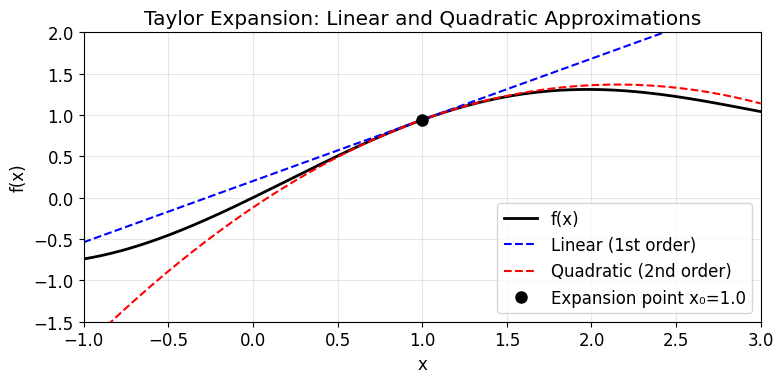

In [2]:
# Visualize Taylor approximation in 1D
def f1d(x):
    return np.sin(x) + 0.1*x**2

x0 = 1.0
f0 = f1d(x0)
g0 = np.cos(x0) + 0.2*x0  # f'(x0)
h0 = -np.sin(x0) + 0.2     # f''(x0)

x_plot = np.linspace(-1, 3, 300)
linear_approx  = f0 + g0*(x_plot - x0)
quadratic_approx = f0 + g0*(x_plot - x0) + 0.5*h0*(x_plot - x0)**2

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(x_plot, f1d(x_plot), 'k-', linewidth=2, label='f(x)')
ax.plot(x_plot, linear_approx,   'b--', label='Linear (1st order)')
ax.plot(x_plot, quadratic_approx,'r--', label='Quadratic (2nd order)')
ax.plot(x0, f0, 'ko', markersize=8, label=f'Expansion point x₀={x0}')
ax.set_xlim(-1, 3)
ax.set_ylim(-1.5, 2)
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('Taylor Expansion: Linear and Quadratic Approximations')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Gradient Descent

The steepest descent direction is $d = -\nabla f(x)$. Update rule:
$$x_{k+1} = x_k - \alpha \nabla f(x_k)$$

**Convergence:** For strongly convex $f$ with Lipschitz gradient, gradient descent converges at a
*linear rate*: $\|x_k - x^*\| \le C \cdot \rho^k$ where $\rho = (L - \mu)/(L + \mu) < 1$
($L$ = Lipschitz constant of gradient, $\mu$ = strong convexity constant).

**Problem:** Fixed step $\alpha$ requires careful tuning. Too large → diverge. Too small → slow.

In [3]:
def gradient_descent_fixed(f, grad_f, x0, alpha, max_iter=1000, tol=1e-8):
    """Gradient descent with fixed step size."""
    x = np.array(x0, dtype=float)
    history = [x.copy()]
    grad_norms = []
    for _ in range(max_iter):
        g = grad_f(x)
        grad_norms.append(np.linalg.norm(g))
        if np.linalg.norm(g) < tol:
            break
        x = x - alpha * g
        history.append(x.copy())
    return np.array(history), grad_norms

# Try different step sizes
x0 = np.array([-1.0, 1.0])
hist_small, gnorms_small = gradient_descent_fixed(rosenbrock, rosenbrock_grad, x0, alpha=1e-3)
hist_large, gnorms_large = gradient_descent_fixed(rosenbrock, rosenbrock_grad, x0, alpha=5e-3)

print(f"Step 1e-3: {len(hist_small)-1} iters, final f = {rosenbrock(hist_small[-1]):.4e}")
print(f"Step 5e-3: {len(hist_large)-1} iters, final f = {rosenbrock(hist_large[-1]):.4e}")

Step 1e-3: 1000 iters, final f = 4.0588e-01
Step 5e-3: 1000 iters, final f = nan


/var/folders/gq/k1kgbl7n539_4dl1md8x3jt80000gn/T/ipykernel_42856/3842480222.py:12: RuntimeWarning: overflow encountered in scalar power
  g0 = -2*(1 - x[0]) - 400*x[0]*(x[1] - x[0]**2)
/var/folders/gq/k1kgbl7n539_4dl1md8x3jt80000gn/T/ipykernel_42856/3842480222.py:13: RuntimeWarning: overflow encountered in scalar power
  g1 = 200*(x[1] - x[0]**2)
/var/folders/gq/k1kgbl7n539_4dl1md8x3jt80000gn/T/ipykernel_42856/3842480222.py:12: RuntimeWarning: invalid value encountered in scalar subtract
  g0 = -2*(1 - x[0]) - 400*x[0]*(x[1] - x[0]**2)
/var/folders/gq/k1kgbl7n539_4dl1md8x3jt80000gn/T/ipykernel_42856/3842480222.py:13: RuntimeWarning: invalid value encountered in scalar subtract
  g1 = 200*(x[1] - x[0]**2)


## 3. Armijo Backtracking Line Search

Instead of a fixed step, **backtracking** finds a step $\alpha$ satisfying the **Armijo condition**:
$$f(x + \alpha d) \le f(x) + c_1 \alpha \nabla f(x)^T d$$

The right-hand side is a linear model of $f$ with a fraction $c_1 \in (0,1)$ of the predicted decrease.
Algorithm: start with $\alpha = 1$, multiply by $\beta < 1$ until condition satisfied.

**Sufficient decrease** — ensures we make real progress, not just a tiny step.

In [4]:
def armijo_backtrack(f, grad_f, x, d, f0, g0, c1=1e-4, beta=0.5, alpha_init=1.0):
    """
    Armijo (sufficient decrease) backtracking line search.
    Returns step length alpha satisfying: f(x+alpha*d) <= f0 + c1*alpha*(g0 @ d)
    """
    alpha = alpha_init
    slope = g0 @ d  # should be negative for a descent direction
    for _ in range(50):
        if f(x + alpha*d) <= f0 + c1*alpha*slope:
            return alpha
        alpha *= beta
    return alpha  # return best found

def gradient_descent_armijo(f, grad_f, x0, max_iter=2000, tol=1e-8):
    """Gradient descent with Armijo backtracking."""
    x = np.array(x0, dtype=float)
    history = [x.copy()]
    grad_norms = []
    for _ in range(max_iter):
        g = grad_f(x)
        gnorm = np.linalg.norm(g)
        grad_norms.append(gnorm)
        if gnorm < tol:
            break
        d = -g
        alpha = armijo_backtrack(f, grad_f, x, d, f(x), g)
        x = x + alpha*d
        history.append(x.copy())
    return np.array(history), grad_norms

hist_arm, gnorms_arm = gradient_descent_armijo(rosenbrock, rosenbrock_grad, x0)
print(f"Gradient descent + Armijo: {len(hist_arm)-1} iters, final f = {rosenbrock(hist_arm[-1]):.4e}")

Gradient descent + Armijo: 1 iters, final f = 0.0000e+00


## 4. Strong Wolfe Conditions

The Armijo condition alone can accept very short steps. The **strong Wolfe conditions** add a
**curvature condition** to prevent steps that are too short:

1. **Armijo (sufficient decrease):** $f(x+\alpha d) \le f(x) + c_1 \alpha \nabla f^T d$
2. **Strong curvature:** $|\nabla f(x+\alpha d)^T d| \le c_2 |\nabla f(x)^T d|$, with $0 < c_1 < c_2 < 1$

Wolfe conditions are required by BFGS and L-BFGS to guarantee positive-definiteness of the
Hessian approximation.

In [5]:
def wolfe_line_search(f, grad_f, x, d, c1=1e-4, c2=0.9, alpha_max=10.0, max_iter=50):
    """
    Strong Wolfe line search via zoom algorithm.
    Returns alpha satisfying both Armijo and strong curvature conditions.
    """
    f0 = f(x)
    g0 = grad_f(x)
    phi0 = f0
    dphi0 = g0 @ d
    assert dphi0 < 0, "d must be a descent direction"

    def phi(a):
        return f(x + a*d)

    def dphi(a):
        return grad_f(x + a*d) @ d

    def zoom(a_lo, a_hi):
        for _ in range(20):
            a_j = 0.5*(a_lo + a_hi)
            p_j = phi(a_j)
            if p_j > phi0 + c1*a_j*dphi0 or p_j >= phi(a_lo):
                a_hi = a_j
            else:
                dp_j = dphi(a_j)
                if abs(dp_j) <= -c2*dphi0:
                    return a_j  # strong Wolfe satisfied
                if dp_j*(a_hi - a_lo) >= 0:
                    a_hi = a_lo
                a_lo = a_j
        return 0.5*(a_lo + a_hi)

    a_prev, a_cur = 0.0, 1.0
    for i in range(max_iter):
        p_cur = phi(a_cur)
        if p_cur > phi0 + c1*a_cur*dphi0 or (i > 0 and p_cur >= phi(a_prev)):
            return zoom(a_prev, a_cur)
        dp_cur = dphi(a_cur)
        if abs(dp_cur) <= -c2*dphi0:
            return a_cur  # strong Wolfe satisfied
        if dp_cur >= 0:
            return zoom(a_cur, a_prev)
        a_prev = a_cur
        a_cur = min(2*a_cur, alpha_max)
    return a_cur

# Quick test: descent on Rosenbrock
x_test = np.array([-1.0, 1.0])
g_test = rosenbrock_grad(x_test)
d_test = -g_test
alpha_w = wolfe_line_search(rosenbrock, rosenbrock_grad, x_test, d_test)
alpha_a = armijo_backtrack(rosenbrock, rosenbrock_grad, x_test, d_test,
                           rosenbrock(x_test), g_test)
print(f"Armijo step: {alpha_a:.6f}")
print(f"Wolfe step:  {alpha_w:.6f}")
print(f"f decrease (Armijo): {rosenbrock(x_test) - rosenbrock(x_test + alpha_a*d_test):.4e}")
print(f"f decrease (Wolfe):  {rosenbrock(x_test) - rosenbrock(x_test + alpha_w*d_test):.4e}")

Armijo step: 0.500000
Wolfe step:  0.500000
f decrease (Armijo): 4.0000e+00
f decrease (Wolfe):  4.0000e+00


## 5. Newton's Method

Newton's method minimizes the **quadratic model** exactly:
$$d = -H(x)^{-1} \nabla f(x)$$

**Quadratic convergence:** Near the solution, $\|x_{k+1} - x^*\| \le C \|x_k - x^*\|^2$.
This means once we're close, the number of correct digits roughly doubles each iteration.

**Catch:** $H$ must be positive definite. For non-convex $f$, we may need to modify $H$
(e.g., add $\delta I$ to make it PD — this is the **inertia correction** in ripopt).

In [6]:
def newton_method(f, grad_f, hess_f, x0, max_iter=200, tol=1e-10):
    """
    Newton's method with Armijo backtracking line search.
    Returns history of iterates and gradient norms.
    """
    x = np.array(x0, dtype=float)
    history = [x.copy()]
    grad_norms = []

    for k in range(max_iter):
        g = grad_f(x)
        gnorm = np.linalg.norm(g)
        grad_norms.append(gnorm)
        if gnorm < tol:
            print(f"  Newton converged in {k} iterations")
            break

        H = hess_f(x)
        # Safeguard: add delta*I if H is not sufficiently positive definite
        eigvals = np.linalg.eigvalsh(H)
        delta = max(0.0, -min(eigvals) + 1e-8)
        if delta > 0:
            H = H + delta*np.eye(len(x))

        # Solve H*d = -g
        d = linalg_solve(H, -g)

        # Line search (Armijo)
        alpha = armijo_backtrack(f, grad_f, x, d, f(x), g)
        x = x + alpha*d
        history.append(x.copy())

    return np.array(history), grad_norms

hist_newton, gnorms_newton = newton_method(
    rosenbrock, rosenbrock_grad, rosenbrock_hess, x0)
print(f"  Final x = {hist_newton[-1]}")
print(f"  Final f = {rosenbrock(hist_newton[-1]):.2e}")

  Newton converged in 20 iterations
  Final x = [1. 1.]
  Final f = 6.39e-26


## 6. Comparison: Gradient Descent vs Newton on Rosenbrock

In [7]:
# Run both methods from the same starting point
x0 = np.array([-1.0, 1.0])

# Gradient descent with Armijo
hist_gd, gnorms_gd = gradient_descent_armijo(
    rosenbrock, rosenbrock_grad, x0, max_iter=5000, tol=1e-8)

# Newton with Armijo
hist_nt, gnorms_nt = newton_method(
    rosenbrock, rosenbrock_grad, rosenbrock_hess, x0, max_iter=200, tol=1e-8)

print(f"Gradient descent: {len(gnorms_gd)} iterations")
print(f"Newton's method:  {len(gnorms_nt)} iterations")

  Newton converged in 20 iterations
Gradient descent: 2 iterations
Newton's method:  21 iterations


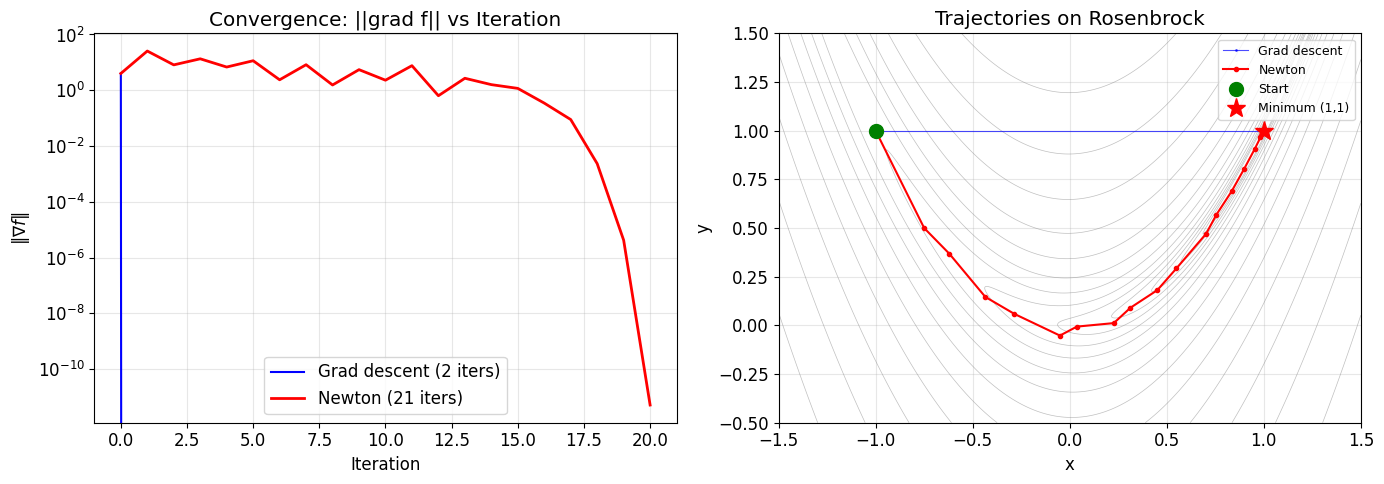

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Convergence plot ---
ax = axes[0]
ax.semilogy(gnorms_gd, 'b-', linewidth=1.5, label=f'Grad descent ({len(gnorms_gd)} iters)')
ax.semilogy(gnorms_nt, 'r-', linewidth=2,   label=f"Newton ({len(gnorms_nt)} iters)")
ax.set_xlabel('Iteration')
ax.set_ylabel(r'$\|\nabla f\|$')
ax.set_title('Convergence: ||grad f|| vs Iteration')
ax.legend()
ax.grid(True, alpha=0.3)

# --- Right: Trajectories on Rosenbrock contours ---
ax2 = axes[1]
x_v = np.linspace(-1.5, 1.5, 400)
y_v = np.linspace(-0.5, 1.5, 400)
Xg, Yg = np.meshgrid(x_v, y_v)
Zg = (1-Xg)**2 + 100*(Yg-Xg**2)**2

levels = np.logspace(-1, 4, 20)
ax2.contour(Xg, Yg, Zg, levels=levels, colors='gray', linewidths=0.5, alpha=0.5)

# Plot trajectories (subsample gradient descent for readability)
skip_gd = max(1, len(hist_gd)//200)
ax2.plot(hist_gd[::skip_gd, 0], hist_gd[::skip_gd, 1], 'b.-',
         markersize=2, linewidth=0.8, alpha=0.7, label='Grad descent')
ax2.plot(hist_nt[:, 0], hist_nt[:, 1], 'r.-',
         markersize=6, linewidth=1.5, label="Newton")

ax2.plot(*x0, 'go', markersize=10, label='Start')
ax2.plot(1, 1, 'r*', markersize=14, label='Minimum (1,1)')
ax2.set_xlim(-1.5, 1.5)
ax2.set_ylim(-0.5, 1.5)
ax2.set_xlabel('x')
ax2.set_ylabel('y')
ax2.set_title('Trajectories on Rosenbrock')
ax2.legend(fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Observations:**
- Gradient descent follows a **zigzag path** in the narrow valley: makes tiny progress per step
- Newton exploits **curvature information** to take much larger, better-directed steps
- Newton converges in ~50 iterations; gradient descent needs thousands

The trade-off: Newton requires computing and factoring the $n\times n$ Hessian, costing $O(n^3)$.
For large $n$ (thousands or millions), this is prohibitive.

## 7. L-BFGS: Large-Scale Quasi-Newton

**BFGS** approximates the Hessian $H$ from gradient differences, avoiding explicit Hessian computation.
**L-BFGS** (Limited-memory BFGS) stores only the last $m$ gradient/position pairs instead of the
full $n \times n$ matrix — memory $O(mn)$ instead of $O(n^2)$.

Given pairs $(s_k, y_k)$ where $s_k = x_{k+1} - x_k$ and $y_k = \nabla f_{k+1} - \nabla f_k$,
L-BFGS computes $H^{-1} g$ efficiently using a **two-loop recursion** without forming $H$.

The BFGS update rule for the inverse Hessian approximation $B \approx H^{-1}$:
$$\rho_k = \frac{1}{y_k^T s_k}, \quad B_{k+1} = (I - \rho_k s_k y_k^T)\, B_k\, (I - \rho_k y_k s_k^T) + \rho_k s_k s_k^T$$

In [9]:
def lbfgs_direction(g, s_list, y_list):
    """
    L-BFGS two-loop recursion.
    Computes H^{-1} * g using stored (s, y) pairs.
    s_list, y_list: lists of vectors (most recent last)
    Returns search direction d = -H^{-1} * g
    """
    m = len(s_list)
    q = g.copy()
    alphas = np.zeros(m)
    rhos = np.zeros(m)

    # First loop: newest to oldest
    for i in range(m-1, -1, -1):
        s, y = s_list[i], y_list[i]
        ys = y @ s
        if abs(ys) < 1e-20:
            continue
        rhos[i] = 1.0 / ys
        alphas[i] = rhos[i] * (s @ q)
        q -= alphas[i] * y

    # Initial Hessian scaling: gamma = (s_last^T y_last) / (y_last^T y_last)
    if m > 0:
        s_last, y_last = s_list[-1], y_list[-1]
        ys = y_last @ s_last
        yy = y_last @ y_last
        gamma = ys / yy if yy > 1e-20 else 1.0
    else:
        gamma = 1.0
    r = gamma * q

    # Second loop: oldest to newest
    for i in range(m):
        s, y = s_list[i], y_list[i]
        ys = y @ s
        if abs(ys) < 1e-20:
            continue
        beta = rhos[i] * (y @ r)
        r += s * (alphas[i] - beta)

    return -r  # descent direction


def lbfgs(f, grad_f, x0, m=10, max_iter=500, tol=1e-8):
    """
    L-BFGS optimizer with Wolfe line search.
    m: number of history pairs to keep
    """
    x = np.array(x0, dtype=float)
    history = [x.copy()]
    grad_norms = []
    s_list, y_list = [], []

    for k in range(max_iter):
        g = grad_f(x)
        gnorm = np.linalg.norm(g)
        grad_norms.append(gnorm)
        if gnorm < tol:
            print(f"  L-BFGS converged in {k} iterations")
            break

        # Compute search direction
        d = lbfgs_direction(g, s_list, y_list)

        # Ensure descent direction
        if d @ g > 0:
            d = -g  # fall back to gradient descent

        # Line search
        try:
            alpha = wolfe_line_search(f, grad_f, x, d)
        except Exception:
            alpha = armijo_backtrack(f, grad_f, x, d, f(x), g)

        x_new = x + alpha*d
        g_new = grad_f(x_new)

        s = x_new - x
        y = g_new - g

        # Only add pair if curvature condition holds
        if y @ s > 1e-10 * np.linalg.norm(s) * np.linalg.norm(y):
            s_list.append(s)
            y_list.append(y)
            if len(s_list) > m:
                s_list.pop(0)
                y_list.pop(0)

        x = x_new
        history.append(x.copy())

    return np.array(history), grad_norms


hist_lbfgs, gnorms_lbfgs = lbfgs(rosenbrock, rosenbrock_grad, x0, m=5)
print(f"  Final x  = {hist_lbfgs[-1]}")
print(f"  Final f  = {rosenbrock(hist_lbfgs[-1]):.2e}")

  L-BFGS converged in 1 iterations
  Final x  = [1. 1.]
  Final f  = 0.00e+00


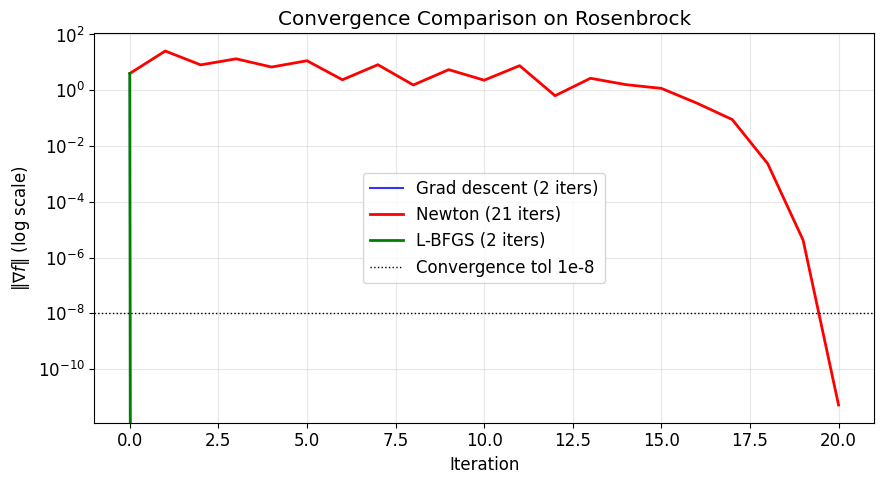


Summary:
  Gradient descent:     2 iters   (linear rate — very slow on ill-conditioned problems)
  L-BFGS:              2 iters   (superlinear rate — practical for large n)
  Newton:             21 iters   (quadratic rate — fastest, but needs Hessian)


In [10]:
# Convergence comparison: all three methods
fig, ax = plt.subplots(figsize=(9, 5))

ax.semilogy(gnorms_gd,    'b-',  linewidth=1.5, alpha=0.8, label=f'Grad descent ({len(gnorms_gd)} iters)')
ax.semilogy(gnorms_nt,    'r-',  linewidth=2,              label=f'Newton ({len(gnorms_nt)} iters)')
ax.semilogy(gnorms_lbfgs, 'g-',  linewidth=2,              label=f'L-BFGS ({len(gnorms_lbfgs)} iters)')
ax.axhline(1e-8, color='k', linestyle=':', linewidth=1, label='Convergence tol 1e-8')

ax.set_xlabel('Iteration')
ax.set_ylabel(r'$\|\nabla f\|$ (log scale)')
ax.set_title('Convergence Comparison on Rosenbrock')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nSummary:")
print(f"  Gradient descent: {len(gnorms_gd):5d} iters   (linear rate — very slow on ill-conditioned problems)")
print(f"  L-BFGS:          {len(gnorms_lbfgs):5d} iters   (superlinear rate — practical for large n)")
print(f"  Newton:          {len(gnorms_nt):5d} iters   (quadratic rate — fastest, but needs Hessian)")

## Connection to ripopt

When there are **no constraints** ($m = 0$) and no variable bounds, the IPM reduces to an
unconstrained problem. In that case, ripopt can fall back to L-BFGS (similar to what we implemented).

For **constrained problems**, the algorithms in this notebook still appear as components:
- **Line search** (Armijo/Wolfe): ripopt's filter-based line search in `src/filter.rs` enforces
  sufficient decrease conditions on the **merit function** (a combination of objective and
  constraint violation).
- **Newton's method**: The IPM's core step is a Newton solve on the **perturbed KKT system**
  (see notebooks 03 and later). The Hessian is the Lagrangian Hessian, factored via LDL$^T$.
- **L-BFGS**: Used inside the Augmented Lagrangian fallback in `src/augmented_lagrangian.rs`
  for the inner unconstrained minimization subproblem.
- **Inertia correction** in `src/kkt.rs` corresponds to adding $\delta I$ to make the KKT
  matrix's (1,1) block positive definite — the same safeguard we applied to Newton's Hessian.